1 Bit LLM

In [3]:
import os
import math
import torch
import torch.nn as nn
import urllib.request as req
import matplotlib.pyplot as plt
from huggingface_hub import HfApi
from torch.nn import functional as F
from transformers import AutoTokenizer
from kaggle_secrets import UserSecretsClient

In [4]:
class BitLinear(nn.Linear):
  def forward(self, x: torch.Tensor):
    # 1. Quantize input activations
    i_scale = x.abs().max(dim=-1, keepdim=True).values.clamp(min=1e-5)
    x_quant = torch.round(x * 127 / i_scale).clamp(-128, 127)
    x_quant = x + (x_quant - x).detach()

    # 2. Quantize weights (Calculate w_quant FIRST!)
    w = self.weight
    w_scale = w.abs().mean().clamp(min=1e-5)
    w_quant = torch.round(w / w_scale).clamp(-1, 1)        # Moved this up
    w_ternary = w + (w_quant - w).detach()

    # 3. Math pass
    out_t = F.linear(x_quant, w_ternary, self.bias)

    # 4. Scale back up
    out_t = out_t * (i_scale / 127) * w_scale
    return out_t

Tests for the BitLinear class

In [5]:
bit_linear_layer = BitLinear(10, 5)
x = torch.randn(1, 10)
output = bit_linear_layer(x)

assert isinstance(output, torch.Tensor), "Assertion Failed: Output should be a torch.Tensor"
assert output.shape == (1, 5), f"Assertion Failed: Output shape mismatch. Expected (1, {5}), got {output.shape}"
assert not torch.isnan(output).any(), "Assertion Failed: Output contains NaN values"
assert not torch.isinf(output).any(), "Assertion Failed: Output contains Inf values"
print(f"Output tensor (first 5 elements): {output.flatten()[:5].tolist()}")

Output tensor (first 5 elements): [0.06843290477991104, 0.1644776463508606, 0.5352505445480347, -1.5080825090408325, -0.8736670017242432]


Replace Linear Layers with BitLinear

In [6]:
def replace_linears_with_bitlinear(model: nn.Module):
  for name, module in model.named_children():
    if isinstance(module, nn.Linear):
      has_bias = module.bias is not None
      bit_layer = BitLinear(module.in_features, module.out_features, bias=has_bias)
      setattr(model, name, bit_layer)
    else:
      replace_linears_with_bitlinear(module)

Test the replacement function

In [7]:
class TestModule(nn.Module):
  def __init__(self):
    super().__init__()
    self.l1, self.relu, self.l2 = nn.Linear(10, 20), nn.ReLU(), nn.Linear(20, 5)

  def forward(self, x):
    return self.l2(self.relu(self.l1(x)))

original_model = TestModule()

print("Original model structure:")
print(original_model)

replace_linears_with_bitlinear(original_model)

print("\nModel structure after replacement:")
print(original_model)

assert isinstance(original_model.l1, BitLinear), "l1 was not replaced by BitLinear"
assert isinstance(original_model.l2, BitLinear), "l2 was not replaced by BitLinear"

Original model structure:
TestModule(
  (l1): Linear(in_features=10, out_features=20, bias=True)
  (relu): ReLU()
  (l2): Linear(in_features=20, out_features=5, bias=True)
)

Model structure after replacement:
TestModule(
  (l1): BitLinear(in_features=10, out_features=20, bias=True)
  (relu): ReLU()
  (l2): BitLinear(in_features=20, out_features=5, bias=True)
)


Setitng up the Transformer Blocks

Tests for RMS Norm Layer

In [8]:
class RMSNorm(nn.Module):
  def __init__(self, dim: int, eps = 1e-6):
    super().__init__()
    self.eps = eps
    self.weight = nn.Parameter(torch.ones(dim))
  def forward(self, x: torch.Tensor):
    var = x.pow(2).mean(dim=-1, keepdim=True)
    return x * torch.rsqrt(var + self.eps) * self.weight

In [9]:
rms_norm_layer = RMSNorm(10)
x_rms = torch.randn(1, 10)
output_rms = rms_norm_layer(x_rms)
assert output_rms.shape == (1, 10), f"Assertion Failed: RMSNorm output shape mismatch. Expected (1, 10), got {output_rms.shape}"
assert not torch.isnan(output_rms).any(), "Assertion Failed: RMSNorm output contains NaN values"
assert not torch.isinf(output_rms).any(), "Assertion Failed: RMSNorm output contains Inf values"
print(f"RMSNorm Output tensor (first 5 elements): {output_rms.flatten()[:5].tolist()}")

RMSNorm Output tensor (first 5 elements): [2.026805877685547, -1.4052903652191162, -1.3777309656143188, -0.6348628401756287, -1.002728819847107]


BitNet Causal Self Attention

In [10]:
class CausalSelfAttention(nn.Module):
  def __init__(self, dim: int, n_heads: int):
    super().__init__()
    self.dim = dim
    self.n_heads = n_heads
    self.head_dim = dim // n_heads
    self.qkv_proj = BitLinear(dim, 3 * dim, bias=False)
    self.out_proj = BitLinear(dim, dim, bias=False)
  def forward(self, x):
    B, T, C = x.shape
    qkv = self.qkv_proj(x)
    q, k, v = qkv.split(self.dim, dim=-1)

    q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
    k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
    v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

    mask = torch.tril(torch.ones(T, T, device=x.device)).bool()
    scores = q @ k.transpose(-1, -2) / math.sqrt(self.head_dim)
    scores = scores.masked_fill(~mask, float("-inf"))
    probs = F.softmax(scores, dim=-1)
    context = probs @ v
    context = context.transpose(1, 2).contiguous().view(B, T, C)
    return self.out_proj(context)

Tests for the CausalSelfAttention class

In [11]:
attention_layer = CausalSelfAttention(dim=64, n_heads=4)
x_attn = torch.randn(1, 10, 64)
output_attn = attention_layer(x_attn)
assert isinstance(output_attn, torch.Tensor), "Assertion Failed: CausalSelfAttention output should be a torch.Tensor"
assert output_attn.shape == (1, 10, 64), f"Assertion Failed: CausalSelfAttention output shape mismatch. Expected (1, 10, 64), got {output_attn.shape}"
assert not torch.isnan(output_attn).any(), "Assertion Failed: CausalSelfAttention output contains NaN values"
assert not torch.isinf(output_attn).any(), "Assertion Failed: CausalSelfAttention output contains Inf values"
print(f"CausalSelfAttention Output tensor shape: {output_attn.shape}")

CausalSelfAttention Output tensor shape: torch.Size([1, 10, 64])


BitNet Feed Forward Layer

In [12]:
from prompt_toolkit.lexers import base
class BitFFN(nn.Module):
  def __init__(self, dim:int, h_dim: int):
    super().__init__()
    self.gate_proj = BitLinear(dim, h_dim, bias=False)
    self.up_proj = BitLinear(dim, h_dim, bias=False)
    self.down_proj = BitLinear(h_dim, dim, bias=False)
  def forward(self, x):
    return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))

Tests for the BitFFN class

In [13]:
ffn_layer = BitFFN(dim=64, h_dim=256)
x_ffn = torch.randn(1, 10, 64)
output_ffn = ffn_layer(x_ffn)
assert isinstance(output_ffn, torch.Tensor), "Assertion Failed: BitFFN output should be a torch.Tensor"
assert output_ffn.shape == (1, 10, 64), f"Assertion Failed: BitFFN output shape mismatch. Expected (1, 10, 64), got {output_ffn.shape}"
assert not torch.isnan(output_ffn).any(), "Assertion Failed: BitFFN output contains NaN values"
assert not torch.isinf(output_ffn).any(), "Assertion Failed: BitFFN output contains Inf values"
print(f"BitFFN Output tensor shape: {output_ffn.shape}")

BitFFN Output tensor shape: torch.Size([1, 10, 64])


Single Transformer Block

In [14]:
class BitBlock(nn.Module):
  def __init__(self, dim: int, n_heads: int, h_dim: int):
    super().__init__()
    self.rn1 = RMSNorm(dim)
    self.rn2 = RMSNorm(dim)
    self.attn = CausalSelfAttention(dim, n_heads)
    self.ffn = BitFFN(dim, h_dim)
  def forward(self, x):
    return x + self.attn(self.rn1(x)) + self.ffn(self.rn2(x))

Tests for the transformer block

In [15]:
bit_block = BitBlock(dim=64, n_heads=4, h_dim=256)
x_block = torch.randn(1, 10, 64)
output_block = bit_block(x_block)
assert isinstance(output_block, torch.Tensor), "Assertion Failed: BitBlock output should be a torch.Tensor"
assert output_block.shape == (1, 10, 64), f"Assertion Failed: BitBlock output shape mismatch. Expected (1, 10, 64), got {output_block.shape}"
assert not torch.isnan(output_block).any(), "Assertion Failed: BitBlock output contains NaN values"
assert not torch.isinf(output_block).any(), "Assertion Failed: BitBlock output contains Inf values"
print(f"BitBlock Output tensor shape: {output_block.shape}")

BitBlock Output tensor shape: torch.Size([1, 10, 64])


The Full BitNet Module

In [16]:
class BitNet(nn.Module):
  def __init__(self, dim: int, vocab_size: int, n_heads: int, h_dim: int, n_layers: int):
    super().__init__()
    self.vocab_size = vocab_size
    self.emb = nn.Embedding(vocab_size + 1, dim, padding_idx=vocab_size)
    self.blocks = nn.ModuleList([BitBlock(dim, n_heads, h_dim) for _ in range(n_layers)])
    self.final_norm = RMSNorm(dim)
    self.lm_head = nn.Linear(dim, vocab_size)
  def forward(self, x, targets=None):
    x = torch.clamp(x, min=0, max=self.vocab_size)
    x = self.emb(x)
    for block in self.blocks:
      x = block(x)
    x = self.final_norm(x)
    logits = self.lm_head(x)
    loss = None
    if targets is not None:
      shift_logits = logits[..., :-1, :]
      shift_targets = targets[..., 1:]
      loss = F.cross_entropy(shift_logits.permute(0, 2, 1), shift_targets)
    return logits, loss

## Tests for the `BitNet` class

In [17]:
vocab_size = 100
max_seq_len = 20
dim = 64
n_heads = 4
h_dim = 256
n_layers = 2

bitnet_model = BitNet(dim=dim, vocab_size=vocab_size, n_heads=n_heads, h_dim=h_dim, n_layers=n_layers)

x_input = torch.randint(0, vocab_size, (1, max_seq_len))
targets_input = torch.randint(0, vocab_size, (1, max_seq_len))
logits, loss = bitnet_model(x_input, targets_input)

assert isinstance(logits, torch.Tensor), "Assertion Failed: BitNet logits should be a torch.Tensor"
assert logits.shape == (1, max_seq_len, vocab_size), f"Assertion Failed: BitNet logits shape mismatch. Expected (1, {max_seq_len}, {vocab_size}), got {logits.shape}"
assert not torch.isnan(logits).any(), "Assertion Failed: BitNet logits contain NaN values"
assert not torch.isinf(logits).any(), "Assertion Failed: BitNet logits contain Inf values"
assert isinstance(loss, torch.Tensor), "Assertion Failed: BitNet loss should be a torch.Tensor"
assert loss.ndim == 0, "Assertion Failed: BitNet loss should be a scalar"
assert not torch.isnan(loss).any(), "Assertion Failed: BitNet loss contains NaN values"
assert not torch.isinf(loss).any(), "Assertion Failed: BitNet loss contains Inf values"
print(f"BitNet Logits shape: {logits.shape}")
print(f"BitNet Loss: {loss.item()}")

BitNet Logits shape: torch.Size([1, 20, 100])
BitNet Loss: 4.894134998321533


Setting up Tokenizer

In [18]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/bitnet-b1.58-2B-4T")
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token
text = "Now tell me, are you working well?"
print(tokenizer.encode(text))
print(tokenizer.pad_token)

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

[128000, 7184, 3371, 757, 11, 527, 499, 3318, 1664, 30]
<|eot_id|>


Hyperparameters

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
h_dim = ((((int(8 * dim / 3)) + 31) // 32) * 32)
vocab_size = tokenizer.vocab_size + 1
dim = 128
n_heads = 4
block_size = 128
batch_size = 16
max_iters = 3000
n_layers = 4
lr = 5e-3
eval_interval = 100
weight_decay = 0.01

Loading Data

In [20]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

try:
    with req.urlopen(url) as response:
        raw_text = response.read().decode('utf-8')
    print("Total Length", len(raw_text))
except:
    print("Text download failed")

corpus = raw_text[:150]
print("Corpus Excerpt: \n", "="*30, "\n", corpus)

Total Length 1115394
Corpus Excerpt: 
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

A


In [21]:
token_ids = tokenizer.encode(raw_text)
data_tensor = torch.tensor(token_ids, dtype=torch.long)
print(data_tensor.shape)

torch.Size([301769])


Train/val split

In [22]:
n = int(0.9 * len(data_tensor))
train_data = data_tensor[:n]
val_data = data_tensor[n:]

Batching

In [23]:
def get_batch(split, device):
    data = train_data if split == "train" else val_data
    ix = torch.randint(0, len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

Training && evaluating the Model

In [24]:
# Estimating Loss
@torch.no_grad()
def estimate_loss(model, device, eval_interval):
    out = {}
    model.eval()

    for split in ["train", "val"]:
        losses = torch.zeros(eval_interval)
        for k in range(eval_interval):
            x_batch, y_batch = get_batch(split, device)
            logits, loss = model(x_batch, y_batch)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [25]:
model = BitNet(dim=dim, vocab_size=vocab_size, n_heads=n_heads, h_dim=h_dim, n_layers=n_layers).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
train_loss_history, val_loss_history = {}, {}

for step in range(max_iters):
    x_batch, y_batch = get_batch("train", device)
    logits, loss = model(x_batch, y_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % eval_interval == 0:
        losses = estimate_loss(model, device, eval_interval)
        train_loss_history[step] = losses["train"]
        val_loss_history[step] = losses["val"]
        print(f"Step {step:4d} | Train Loss: {losses['train']:.5f} | Val Loss: {losses['val']:.5f}")

Step    0 | Train Loss: 11.84090 | Val Loss: 11.84739
Step  100 | Train Loss: 6.40983 | Val Loss: 7.05739
Step  200 | Train Loss: 6.06356 | Val Loss: 6.93377
Step  300 | Train Loss: 5.80353 | Val Loss: 6.85732
Step  400 | Train Loss: 5.56947 | Val Loss: 6.96417
Step  500 | Train Loss: 5.42022 | Val Loss: 6.95713
Step  600 | Train Loss: 5.30050 | Val Loss: 6.98490
Step  700 | Train Loss: 5.19490 | Val Loss: 7.05383
Step  800 | Train Loss: 5.06867 | Val Loss: 7.09438
Step  900 | Train Loss: 5.00271 | Val Loss: 7.14167
Step 1000 | Train Loss: 4.93791 | Val Loss: 7.18537
Step 1100 | Train Loss: 4.84096 | Val Loss: 7.19753
Step 1200 | Train Loss: 4.82540 | Val Loss: 7.17451
Step 1300 | Train Loss: 4.78399 | Val Loss: 7.25895
Step 1400 | Train Loss: 4.71368 | Val Loss: 7.27353
Step 1500 | Train Loss: 4.66525 | Val Loss: 7.31988
Step 1600 | Train Loss: 4.64314 | Val Loss: 7.30319
Step 1700 | Train Loss: 4.61826 | Val Loss: 7.38831
Step 1800 | Train Loss: 4.60058 | Val Loss: 7.43855
Step 1900 

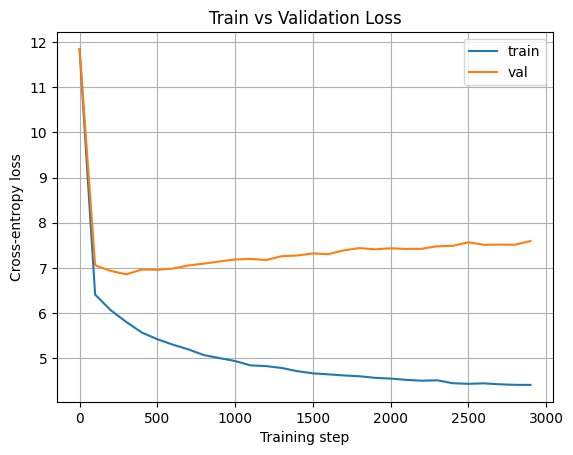

In [26]:
plt.plot(train_loss_history.keys(), train_loss_history.values(), label="train")
plt.plot(val_loss_history.keys(), val_loss_history.values(), label="val")

plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Prompt Text

In [27]:
temperature = 0.6

In [28]:
def generate_text(model, prompt, max_new_tokens=20):
    model.to(device)
    model.eval()
    generated_indices = tokenizer.encode(prompt)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = generated_indices[-block_size:]
            input_tensor = torch.tensor([context], dtype=torch.long, device=device)
            logits, _ = model(input_tensor)
            next_token_logits = logits[0, -1, :]
            probs = F.softmax(next_token_logits / temperature, dim = -1)
            next_token = torch.multinomial(probs, num_samples = 1).item()
            generated_indices.append(next_token)
    return tokenizer.decode(generated_indices)

In [34]:
prompt = "FIRST CITIZEN"
print(generate_text(model, prompt, max_new_tokens=20))

<|begin_of_text|>FIRST CITIZENIZETHAs aeric,
er a?

 MessengerSuch of,
 thou, do to and kill him


Parameters Count Check

In [30]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")

Trainable parameters: 33,454,593
Total parameters: 33,454,593


Save Model Weights

In [31]:
os.makedirs("model", exist_ok=True)
torch.save(model.state_dict(), "model/bitnet_b158.pt")

Push to Huggingface

In [32]:
user_secrets = UserSecretsClient()
secret_value = user_secrets.get_secret("HF_TOKEN")

In [33]:
api = HfApi(token=user_secrets.get_secret("HF_TOKEN"))
api.upload_folder(
    folder_path="model",
    repo_id="Bukunmi2108/bitnet",
    repo_type="model",
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/Bukunmi2108/bitnet/commit/93ce66491428b836d6605fe41397e29f4b3c6ee2', commit_message='Upload folder using huggingface_hub', commit_description='', oid='93ce66491428b836d6605fe41397e29f4b3c6ee2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Bukunmi2108/bitnet', endpoint='https://huggingface.co', repo_type='model', repo_id='Bukunmi2108/bitnet'), pr_revision=None, pr_num=None)